<a href="https://colab.research.google.com/github/luu-quang/Data_Mining_and_Machine_Learning_USTH/blob/Khanh/test_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install display
import missingno as msno
import gc #dùng nguyên 11tr hàng nên phải xoá bớt khỏi ram

from google.colab import drive
#drive ngáo lắm phải forece_remount
drive.mount("/content/drive", force_remount=True)

  Preparing metadata (setup.py) ... done
  Created wheel for display: filename=display-1.0.0-py3-none-any.whl size=1380 sha256=5f561c8d146824ea0ad2cf74af2966b0c75aef14b34a2a6812c4da690c7a54a3
  Stored in directory: /root/.cache/pip/wheels/aa/37/3e/1ab7472ef100105e66476aec658aa95980b913260d4b48fcdc
Successfully built display
Mounted at /content/drive


In [ ]:
test_csv = "/content/drive/My Drive/bank_data/test.csv"
df = pd.read_csv(test_csv)
display(df.head())
display(df.info())
display(df.isnull().sum())

/tmp/ipykernel_1302/3649000096.py:2: DtypeWarning: Columns (11,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(test_csv)


,date,customer_code,employee_index,customer_country,sex,age,first_contract_date,new_index,seniority_months,primary_customer,...,product_15,product_16,product_17,product_18,product_19,product_20,product_21,product_22,product_23,product_24
0,2016-05-28,657640,N,ES,H,68,2006-11-17,0.0,114,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
1,2016-05-28,657788,N,ES,H,42,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
2,2016-05-28,657795,N,ES,V,44,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0
3,2016-05-28,657790,N,ES,V,42,2006-11-18,0.0,114,1.0,...,0,0,0,0,1,0,0,1.0,1.0,1
4,2016-05-28,657794,N,ES,H,49,2006-11-18,0.0,114,1.0,...,0,0,0,0,0,0,0,0.0,0.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931453 entries, 0 to 931452
Data columns (total 48 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date                    931453 non-null  object 
 1   customer_code           931453 non-null  int64  
 2   employee_index          931453 non-null  object 
 3   customer_country        931453 non-null  object 
 4   sex                     931448 non-null  object 
 5   age                     931453 non-null  int64  
 6   first_contract_date     931453 non-null  object 
 7   new_index               931453 non-null  float64
 8   seniority_months        931453 non-null  int64  
 9   primary_customer        931453 non-null  float64
 10  last_date_primary       1870 non-null    object 
 11  month_start_type        927443 non-null  object 
 12  relation_type           927443 non-null  object 
 13  residence_index         931453 non-null  object 
 14  foreigner_index     

None

,0
date,0
customer_code,0
employee_index,0
customer_country,0
sex,5
age,0
first_contract_date,0
new_index,0
seniority_months,0
primary_customer,0


In [ ]:
columns = ['fecha_dato', 'ncodpers', 'ind_empleado', 'pais_residencia', 'sexo',
       'age', 'fecha_alta', 'ind_nuevo', 'antiguedad', 'indrel',
       'ult_fec_cli_1t', 'indrel_1mes', 'tiprel_1mes', 'indresi', 'indext',
       'conyuemp', 'canal_entrada', 'indfall', 'tipodom', 'cod_prov',
       'nomprov', 'ind_actividad_cliente', 'renta', 'segmento',
       'ind_ahor_fin_ult1', 'ind_aval_fin_ult1', 'ind_cco_fin_ult1',
       'ind_cder_fin_ult1', 'ind_cno_fin_ult1', 'ind_ctju_fin_ult1',
       'ind_ctma_fin_ult1', 'ind_ctop_fin_ult1', 'ind_ctpp_fin_ult1',
       'ind_deco_fin_ult1', 'ind_deme_fin_ult1', 'ind_dela_fin_ult1',
       'ind_ecue_fin_ult1', 'ind_fond_fin_ult1', 'ind_hip_fin_ult1',
       'ind_plan_fin_ult1', 'ind_pres_fin_ult1', 'ind_reca_fin_ult1',
       'ind_tjcr_fin_ult1', 'ind_valo_fin_ult1', 'ind_viv_fin_ult1',
       'ind_nomina_ult1', 'ind_nom_pens_ult1', 'ind_recibo_ult1']
new_columns = ["date","customer_code","employee_index","customer_country","sex",
               "age","first_contract_date","new_index","seniority_months","primary_customer",
               "last_date_primary","month_start_type","relation_type","residence_index",
               "foreigner_index","spouse_index","join_channel","deceased_index","address_type",
               "province_code","province_name","activity_index","gross_househole_income",
               "segment","product_1","product_2","product_3","product_4","product_5",
               "product_6","product_7","product_8","product_9","product_10","product_11",
               "product_12","product_13","product_14","product_15","product_16",
               "product_17","product_18","product_19","product_20","product_21",
               "product_22","product_23","product_24"]

In [ ]:
df.to_csv(test_csv, header=new_columns, index=False)

In [ ]:
gross_income_means = {'00401 - TOP': np.float64(247776.62999999998), '00402 - PARTICULARES': np.float64(124099.38375000001), '00701 - TOP': np.float64(207315.37576800692), '00702 - PARTICULARES': np.float64(185854.44434523213), '00703 - UNIVERSITARIO': np.float64(224703.50249999997), '01301 - TOP': np.float64(209786.87258964145), '01302 - PARTICULARES': np.float64(111224.69133140512), 'K0002 - PARTICULARES': np.float64(151768.5324), 'K0003 - UNIVERSITARIO': np.float64(122605.94999999998), 'KAA01 - TOP': np.float64(185684.89107187896), 'KAA02 - PARTICULARES': np.float64(187367.37008148004), 'KAA03 - UNIVERSITARIO': np.float64(222470.85378048779), 'KAB01 - TOP': np.float64(125115.74942789035), 'KAB02 - PARTICULARES': np.float64(118841.56149832164), 'KAB03 - UNIVERSITARIO': np.float64(113614.5003468208), 'KAC01 - TOP': np.float64(108373.5017647059), 'KAC02 - PARTICULARES': np.float64(122293.0106043956), 'KAC03 - UNIVERSITARIO': np.float64(100877.21999999999), 'KAD01 - TOP': np.float64(121831.862754591), 'KAD02 - PARTICULARES': np.float64(109943.69537616763), 'KAD03 - UNIVERSITARIO': np.float64(80512.36499999999), 'KAE01 - TOP': np.float64(134090.07824797844), 'KAE02 - PARTICULARES': np.float64(113637.38939746705), 'KAE03 - UNIVERSITARIO': np.float64(115531.8206896552), 'KAF01 - TOP': np.float64(133927.1795192308), 'KAF02 - PARTICULARES': np.float64(137622.97564580385), 'KAF03 - UNIVERSITARIO': np.float64(235034.21158671592), 'KAG01 - TOP': np.float64(172528.10615720524), 'KAG02 - PARTICULARES': np.float64(161076.78100474493), 'KAG03 - UNIVERSITARIO': np.float64(169332.62703604804), 'KAH01 - TOP': np.float64(155138.31825278807), 'KAH02 - PARTICULARES': np.float64(142294.27665282963), 'KAH03 - UNIVERSITARIO': np.float64(140319.10499999998), 'KAI01 - TOP': np.float64(173119.48808823523), 'KAI02 - PARTICULARES': np.float64(129969.60491885142), 'KAI03 - UNIVERSITARIO': np.float64(177898.25999999995), 'KAJ01 - TOP': np.float64(119908.10038116593), 'KAJ02 - PARTICULARES': np.float64(109838.35559299466), 'KAJ03 - UNIVERSITARIO': np.float64(84207.66661016947), 'KAK02 - PARTICULARES': np.float64(114671.79164978293), 'KAL01 - TOP': np.float64(94942.65406779661), 'KAL02 - PARTICULARES': np.float64(114934.73078501629), 'KAL03 - UNIVERSITARIO': np.float64(108574.53000000001), 'KAM01 - TOP': np.float64(152060.50112359552), 'KAM02 - PARTICULARES': np.float64(141442.45245283018), 'KAM03 - UNIVERSITARIO': np.float64(285186.62999999995), 'KAN01 - TOP': np.float64(107841.03000000001), 'KAN02 - PARTICULARES': np.float64(86987.48163934426), 'KAN03 - UNIVERSITARIO': 0, 'KAO01 - TOP': np.float64(112170.15537313433), 'KAO02 - PARTICULARES': np.float64(91352.51772736011), 'KAO03 - UNIVERSITARIO': np.float64(83912.3487804878), 'KAP01 - TOP': np.float64(126933.11065281898), 'KAP02 - PARTICULARES': np.float64(105905.95019347999), 'KAP03 - UNIVERSITARIO': np.float64(124347.70216216217), 'KAQ01 - TOP': np.float64(125471.67888888891), 'KAQ02 - PARTICULARES': np.float64(112324.5216365925), 'KAQ03 - UNIVERSITARIO': np.float64(220116.32830985918), 'KAR01 - TOP': np.float64(199599.19524937024), 'KAR02 - PARTICULARES': np.float64(180278.53143054317), 'KAR03 - UNIVERSITARIO': np.float64(283423.78251162794), 'KAS01 - TOP': np.float64(208712.47211447987), 'KAS02 - PARTICULARES': np.float64(160684.42586646913), 'KAS03 - UNIVERSITARIO': np.float64(201745.63467153284), 'KAT01 - TOP': np.float64(183064.9306458788), 'KAT02 - PARTICULARES': np.float64(151012.43657165396), 'KAT03 - UNIVERSITARIO': np.float64(132038.35940264683), 'KAU01 - TOP': np.float64(155804.13), 'KAU02 - PARTICULARES': np.float64(121103.40838709676), 'KAV01 - TOP': np.float64(86977.3248), 'KAV02 - PARTICULARES': np.float64(203061.56763157892), 'KAW01 - TOP': np.float64(156126.6927415966), 'KAW02 - PARTICULARES': np.float64(132946.78526053467), 'KAW03 - UNIVERSITARIO': np.float64(154534.27050445107), 'KAY01 - TOP': np.float64(166805.10241687982), 'KAY02 - PARTICULARES': np.float64(127668.18114525256), 'KAY03 - UNIVERSITARIO': np.float64(286277.175), 'KAZ01 - TOP': np.float64(167085.54876039934), 'KAZ02 - PARTICULARES': np.float64(119371.43124562992), 'KAZ03 - UNIVERSITARIO': np.float64(131802.5588078109), 'KBB01 - TOP': np.float64(119602.8825), 'KBB02 - PARTICULARES': np.float64(200203.42147239269), 'KBD01 - TOP': np.float64(173656.38), 'KBD02 - PARTICULARES': np.float64(100535.57934065933), 'KBE01 - TOP': np.float64(73244.79000000001), 'KBE02 - PARTICULARES': np.float64(123347.41186046509), 'KBF01 - TOP': np.float64(135972.66028571426), 'KBF02 - PARTICULARES': np.float64(159615.89324404765), 'KBG01 - TOP': np.float64(164947.27626506027), 'KBG02 - PARTICULARES': np.float64(154943.8546822204), 'KBG03 - UNIVERSITARIO': np.float64(135054.01845070423), 'KBH01 - TOP': np.float64(232156.33747058822), 'KBH02 - PARTICULARES': np.float64(146873.28354968096), 'KBH03 - UNIVERSITARIO': np.float64(353620.89), 'KBJ02 - PARTICULARES': np.float64(95457.69958904108), 'KBL01 - TOP': np.float64(289421.807037037), 'KBL02 - PARTICULARES': np.float64(211437.94602941175), 'KBM01 - TOP': np.float64(91921.86000000002), 'KBM02 - PARTICULARES': np.float64(121340.16829145727), 'KBM03 - UNIVERSITARIO': np.float64(600723.4), 'KBN02 - PARTICULARES': np.float64(53721.1725), 'KBO01 - TOP': np.float64(210281.71835820892), 'KBO02 - PARTICULARES': np.float64(225470.24385083173), 'KBO03 - UNIVERSITARIO': np.float64(135042.51), 'KBP01 - TOP': np.float64(61677.51), 'KBP02 - PARTICULARES': np.float64(190908.80999999997), 'KBQ01 - TOP': np.float64(204041.62178571432), 'KBQ02 - PARTICULARES': np.float64(152644.97625), 'KBQ03 - UNIVERSITARIO': np.float64(100484.69999999998), 'KBR01 - TOP': np.float64(109807.34076923077), 'KBR02 - PARTICULARES': np.float64(105190.48691964285), 'KBR03 - UNIVERSITARIO': 0, 'KBS02 - PARTICULARES': np.float64(115690.69830845771), 'KBU01 - TOP': np.float64(180195.1892763158), 'KBU02 - PARTICULARES': np.float64(126370.1496867168), 'KBV01 - TOP': np.float64(153521.52000000002), 'KBV02 - PARTICULARES': np.float64(145754.31087621697), 'KBW01 - TOP': np.float64(127558.06901408451), 'KBW02 - PARTICULARES': np.float64(149481.86085995086), 'KBX01 - TOP': np.float64(141299.58000000005), 'KBX02 - PARTICULARES': np.float64(126115.43142857144), 'KBY01 - TOP': np.float64(166367.16999999998), 'KBY02 - PARTICULARES': np.float64(130423.47626373627), 'KBZ01 - TOP': np.float64(205651.89706744868), 'KBZ02 - PARTICULARES': np.float64(185407.8026470834), 'KBZ03 - UNIVERSITARIO': np.float64(243091.00114624508), 'KCA01 - TOP': np.float64(80683.48999999995), 'KCA02 - PARTICULARES': np.float64(170523.0778125), 'KCA03 - UNIVERSITARIO': np.float64(144348.3), 'KCB01 - TOP': np.float64(103542.00695652173), 'KCB02 - PARTICULARES': np.float64(110373.58716196139), 'KCC01 - TOP': np.float64(221004.27041553747), 'KCC02 - PARTICULARES': np.float64(221245.4610453008), 'KCC03 - UNIVERSITARIO': np.float64(199039.27503386003), 'KCD01 - TOP': np.float64(153055.83750000002), 'KCD02 - PARTICULARES': np.float64(231449.86486796784), 'KCE02 - PARTICULARES': np.float64(297533.4723529411), 'KCF01 - TOP': np.float64(65680.41000000002), 'KCF02 - PARTICULARES': np.float64(233045.16513698635), 'KCG01 - TOP': np.float64(225184.45003984062), 'KCG02 - PARTICULARES': np.float64(231061.14384142015), 'KCH01 - TOP': np.float64(112065.50472527473), 'KCH02 - PARTICULARES': np.float64(112144.93278885099), 'KCH03 - UNIVERSITARIO': np.float64(135769.71202453985), 'KCI01 - TOP': np.float64(172396.7746200608), 'KCI02 - PARTICULARES': np.float64(153684.64675931714), 'KCI03 - UNIVERSITARIO': np.float64(185333.61261627908), 'KCJ01 - TOP': np.float64(76284.75), 'KCJ02 - PARTICULARES': np.float64(225142.14584415586), 'KCK02 - PARTICULARES': np.float64(94044.45810040704), 'KCL01 - TOP': np.float64(119267.82880733945), 'KCL02 - PARTICULARES': np.float64(116352.45584276358), 'KCL03 - UNIVERSITARIO': np.float64(109318.37999999998), 'KCM01 - TOP': np.float64(146418.00845070425), 'KCM02 - PARTICULARES': np.float64(101277.30239452679), 'KCN01 - TOP': np.float64(105221.53285714285), 'KCN02 - PARTICULARES': np.float64(92602.43866242036), 'KCO01 - TOP': np.float64(103383.84000000001), 'KCO02 - PARTICULARES': np.float64(95262.91500000001), 'KCP02 - PARTICULARES': np.float64(80562.3608108108), 'KCQ02 - PARTICULARES': np.float64(125155.65), 'KCR02 - PARTICULARES': np.float64(132732.1371428572), 'KCS02 - PARTICULARES': np.float64(136268.90873239437), 'KCT02 - PARTICULARES': np.float64(187591.61999999997), 'KCU01 - TOP': np.float64(233526.00720000002), 'KCU02 - PARTICULARES': np.float64(217163.7882880435), 'KCV02 - PARTICULARES': np.float64(239758.7607920792), 'KCX02 - PARTICULARES': np.float64(100122.36652173914), 'KDA02 - PARTICULARES': np.float64(112187.47884476531), 'KDB02 - PARTICULARES': np.float64(210914.33999999997), 'KDC01 - TOP': np.float64(134961.12000000002), 'KDC02 - PARTICULARES': np.float64(138667.43142066424), 'KDD01 - TOP': np.float64(202312.95000000004), 'KDD02 - PARTICULARES': np.float64(168423.23372093023), 'KDE01 - TOP': np.float64(138388.98285714287), 'KDE02 - PARTICULARES': np.float64(182019.61796178343), 'KDF01 - TOP': np.float64(109358.52), 'KDF02 - PARTICULARES': np.float64(126698.21729411762), 'KDG02 - PARTICULARES': np.float64(125179.79218309859), 'KDH02 - PARTICULARES': np.float64(175154.60081632657), 'KDH03 - UNIVERSITARIO': np.float64(151902.25499999998), 'KDI02 - PARTICULARES': np.float64(65717.64), 'KDM01 - TOP': np.float64(104069.4440425532), 'KDM02 - PARTICULARES': np.float64(107648.97056838367), 'KDM03 - UNIVERSITARIO': np.float64(108225.87000000002), 'KDN01 - TOP': np.float64(78025.92), 'KDN02 - PARTICULARES': np.float64(117586.08499999998), 'KDO01 - TOP': np.float64(79000.45421052634), 'KDO02 - PARTICULARES': np.float64(83435.78285714287), 'KDP01 - TOP': 0, 'KDP02 - PARTICULARES': np.float64(78050.35735955057), 'KDQ01 - TOP': np.float64(117382.98999999999), 'KDQ02 - PARTICULARES': np.float64(79304.41948955916),
                      'KDR01 - TOP': np.float64(136338.15895348837), 'KDR02 - PARTICULARES': np.float64(91317.6018728092), 'KDS01 - TOP': 0, 'KDS02 - PARTICULARES': np.float64(73616.5093256815), 'KDT01 - TOP': np.float64(66501.84638297872), 'KDT02 - PARTICULARES': np.float64(73333.68516536965), 'KDT03 - UNIVERSITARIO': np.float64(86102.34), 'KDU01 - TOP': np.float64(84234.30833333332), 'KDU02 - PARTICULARES': np.float64(70886.29767203514), 'KDV02 - PARTICULARES': np.float64(80095.63742647057), 'KDW01 - TOP': np.float64(177710.40000000005), 'KDW02 - PARTICULARES': np.float64(248900.0454545455), 'KDX01 - TOP': 0, 'KDX02 - PARTICULARES': np.float64(150751.61153374234), 'KDY01 - TOP': np.float64(89259.06000000001), 'KDY02 - PARTICULARES': np.float64(105924.0882), 'KDZ01 - TOP': 0, 'KDZ02 - PARTICULARES': np.float64(71746.16249999999), 'KEA01 - TOP': 0, 'KEA02 - PARTICULARES': np.float64(86492.74948979594), 'KEB02 - PARTICULARES': np.float64(78536.65603448277), 'KEC02 - PARTICULARES': np.float64(92606.47901639344), 'KED01 - TOP': np.float64(99191.61000000003), 'KED02 - PARTICULARES': np.float64(103162.27734374999), 'KEE02 - PARTICULARES': np.float64(126881.52), 'KEF01 - TOP': np.float64(73178.09999999999), 'KEF02 - PARTICULARES': np.float64(125371.85258064515), 'KEG01 - TOP': np.float64(127471.3532967033), 'KEG02 - PARTICULARES': np.float64(111270.31037302726), 'KEH02 - PARTICULARES': np.float64(76991.75861842102), 'KEH03 - UNIVERSITARIO': np.float64(117856.31411009177), 'KEI02 - PARTICULARES': np.float64(62891.42335766422), 'KEJ01 - TOP': np.float64(143998.81536290323), 'KEJ02 - PARTICULARES': np.float64(111026.00973573823), 'KEJ03 - UNIVERSITARIO': np.float64(69848.44), 'KEK01 - TOP': np.float64(370657.86000000004), 'KEK02 - PARTICULARES': np.float64(128528.05854077253), 'KEL01 - TOP': np.float64(146887.78717105265), 'KEL02 - PARTICULARES': np.float64(137407.4395059625), 'KEM02 - PARTICULARES': np.float64(87019.65000000001), 'KEN01 - TOP': np.float64(118304.0685714286), 'KEN02 - PARTICULARES': np.float64(101070.35069767444), 'KEN03 - UNIVERSITARIO': np.float64(108193.43000000001), 'KEO01 - TOP': np.float64(99891.69272727269), 'KEO02 - PARTICULARES': np.float64(110672.41724659606), 'KEQ02 - PARTICULARES': np.float64(195410.69999999998), 'KES01 - TOP': np.float64(144752.68285714285), 'KES02 - PARTICULARES': np.float64(134031.4838456189), 'KEU02 - PARTICULARES': np.float64(96177.42491379309), 'KEV01 - TOP': 0, 'KEV02 - PARTICULARES': np.float64(179362.63004999995), 'KEW02 - PARTICULARES': np.float64(78231.57656658595), 'KEY01 - TOP': np.float64(138095.18739130435), 'KEY02 - PARTICULARES': np.float64(115563.8128499339), 'KEY03 - UNIVERSITARIO': np.float64(88167.105), 'KEZ01 - TOP': np.float64(137225.9080851064), 'KEZ02 - PARTICULARES': np.float64(143000.91836990596), 'KEZ03 - UNIVERSITARIO': np.float64(201412.70271565497), 'KFA01 - TOP': np.float64(207582.5880966632), 'KFA02 - PARTICULARES': np.float64(174756.09757937116), 'KFA03 - UNIVERSITARIO': np.float64(187432.5361780065), 'KFB02 - PARTICULARES': np.float64(175347.285), 'KFC01 - TOP': np.float64(161089.6006636722), 'KFC02 - PARTICULARES': np.float64(133859.81188359077), 'KFC03 - UNIVERSITARIO': np.float64(144709.58933670569), 'KFD01 - TOP': np.float64(167200.63356127887), 'KFD02 - PARTICULARES': np.float64(173806.30382492862), 'KFD03 - UNIVERSITARIO': np.float64(168451.09773195875), 'KFE02 - PARTICULARES': np.float64(98299.81764705884), 'KFF01 - TOP': np.float64(207013.23489795916), 'KFF02 - PARTICULARES': np.float64(136942.39699189053), 'KFF03 - UNIVERSITARIO': np.float64(104563.54714285715), 'KFG01 - TOP': np.float64(109135.40546666668), 'KFG02 - PARTICULARES': np.float64(108209.52670743359), 'KFG03 - UNIVERSITARIO': np.float64(62698.45434782608), 'KFH01 - TOP': np.float64(94201.67999999996), 'KFH02 - PARTICULARES': np.float64(89955.91972392637), 'KFI01 - TOP': np.float64(68702.73), 'KFI02 - PARTICULARES': np.float64(114591.82391566267), 'KFI03 - UNIVERSITARIO': np.float64(107782.24500000001), 'KFJ01 - TOP': np.float64(118381.19440000001), 'KFJ02 - PARTICULARES': np.float64(109008.51644702586), 'KFJ03 - UNIVERSITARIO': np.float64(111103.60976878612), 'KFK01 - TOP': np.float64(143568.90586466168), 'KFK02 - PARTICULARES': np.float64(106224.26883754002), 'KFK03 - UNIVERSITARIO': np.float64(96326.73749999999), 'KFL01 - TOP': 0, 'KFL02 - PARTICULARES': np.float64(218864.7142857143), 'KFL03 - UNIVERSITARIO': 0, 'KFM01 - TOP': np.float64(69408.27), 'KFM02 - PARTICULARES': np.float64(120071.27796992482), 'KFN01 - TOP': np.float64(133448.55000000002), 'KFN02 - PARTICULARES': np.float64(119278.31368421055), 'KFN03 - UNIVERSITARIO': np.float64(110290.21500000001), 'KFP01 - TOP': np.float64(124397.13168900808), 'KFP02 - PARTICULARES': np.float64(114127.90055398128), 'KFP03 - UNIVERSITARIO': np.float64(141009.818560606), 'KFR02 - PARTICULARES': 0, 'KFS01 - TOP': np.float64(97616.75242718446), 'KFS02 - PARTICULARES': np.float64(104114.40941910412), 'KFS03 - UNIVERSITARIO': np.float64(105742.70249999997), 'KFT01 - TOP': np.float64(139038.08804081634), 'KFT02 - PARTICULARES': np.float64(136637.00581933098), 'KFT03 - UNIVERSITARIO': np.float64(184176.43714285718), 'KFU01 - TOP': np.float64(103070.33071428568), 'KFU02 - PARTICULARES': np.float64(96235.46393755422), 'KFU03 - UNIVERSITARIO': np.float64(98723.76), 'KFV02 - PARTICULARES': np.float64(118900.7376923077), 'KGC03 - UNIVERSITARIO': np.float64(32626.890000000007), 'KGN02 - PARTICULARES': 0, 'KGU02 - PARTICULARES': np.float64(100900.66384615387), 'KGV01 - TOP': np.float64(119825.17245535715), 'KGV02 - PARTICULARES': np.float64(100030.3956813266), 'KGV03 - UNIVERSITARIO': np.float64(111204.54499999997), 'KGW01 - TOP': np.float64(154073.34000000003), 'KGW02 - PARTICULARES': np.float64(108099.61514999998), 'KGW03 - UNIVERSITARIO': np.float64(92330.25), 'KGX01 - TOP': np.float64(198743.46731875718), 'KGX02 - PARTICULARES': np.float64(224459.4181574369), 'KGX03 - UNIVERSITARIO': np.float64(281756.1152419355), 'KGY01 - TOP': np.float64(60414.08999999998), 'KGY02 - PARTICULARES': np.float64(164372.14565217393), 'KGY03 - UNIVERSITARIO': 0, 'KHA02 - PARTICULARES': np.float64(126276.72), 'KHA03 - UNIVERSITARIO': np.float64(162766.20000000004), 'KHC01 - TOP': np.float64(182363.10161870503), 'KHC02 - PARTICULARES': np.float64(121702.35337185413), 'KHC03 - UNIVERSITARIO': np.float64(159591.21966666667), 'KHD02 - PARTICULARES': np.float64(108554.73553346755), 'KHD03 - UNIVERSITARIO': np.float64(112917.36656170477), 'KHE01 - TOP': np.float64(129868.34806451615), 'KHE02 - PARTICULARES': np.float64(103461.63939564426), 'KHE03 - UNIVERSITARIO': np.float64(114044.7744081031), 'KHF02 - PARTICULARES': np.float64(111940.00720422005), 'KHF03 - UNIVERSITARIO': np.float64(155654.08055534054), 'KHK01 - TOP': np.float64(147652.69886157828), 'KHK02 - PARTICULARES': np.float64(113222.87494688433), 'KHK03 - UNIVERSITARIO': np.float64(120470.28932715532), 'KHL01 - TOP': np.float64(142255.5831826087), 'KHL02 - PARTICULARES': np.float64(111966.47966029578), 'KHL03 - UNIVERSITARIO': np.float64(125266.85978005866), 'KHM01 - TOP': np.float64(129332.12435732012), 'KHM02 - PARTICULARES': np.float64(109559.80580342517), 'KHM03 - UNIVERSITARIO': np.float64(173482.59009745845), 'KHN01 - TOP': np.float64(130375.35565344222), 'KHN02 - PARTICULARES': np.float64(110445.71682087725), 'KHN03 - UNIVERSITARIO': np.float64(115065.75983749273), 'KHO01 - TOP': np.float64(160996.68950053136), 'KHO03 - UNIVERSITARIO': np.float64(161855.64034582133), 'RED01 - TOP': np.float64(157246.1278515625), 'RED02 - PARTICULARES': np.float64(118227.09469144566), 'RED03 - UNIVERSITARIO': np.float64(120716.90305666042), 'KHO02 - PARTICULARES': np.float64(133703.8354768041), 'KHQ03 - UNIVERSITARIO': np.float64(111343.99891993431), 'KDL02 - PARTICULARES': np.float64(194531.88), 'KFH03 - UNIVERSITARIO': np.float64(99654.36000000002), 'KGC02 - PARTICULARES': np.float64(140518.38), '02502 - PARTICULARES': 0, 'KHP02 - PARTICULARES': np.float64(72482.52), 'KHP03 - UNIVERSITARIO': np.float64(107182.05855737705), 'KHQ02 - PARTICULARES': np.float64(104274.04733991278), '01303 - UNIVERSITARIO': np.float64(254905.95000000004), 'KAK01 - TOP': np.float64(184807.59545454543), 'KCN03 - UNIVERSITARIO': np.float64(100479.15000000001), 'KHQ01 - TOP': np.float64(75929.13), 'KCK01 - TOP': np.float64(127714.0875), 'KEB01 - TOP': np.float64(85341.06), 'KEC01 - TOP': np.float64(160003.74)}

In [ ]:
df.drop(columns=['last_date_primary', 'spouse_index'], inplace=True)
important_columns = ['new_index', 'seniority_months', 'primary_customer', 'month_start_type', 'join_channel', 'activity_index', 'gross_househole_income', 'segment']
df = df[df[important_columns].isnull().sum(axis=1) < 3]
df['gross_househole_income'] = pd.to_numeric(df['gross_househole_income'], errors='coerce')
grouped = df.groupby(['join_channel', 'segment'])['gross_househole_income'].mean()
income_mean = df['gross_househole_income'].mean()
for key in grouped.index:
  df.loc[(df['join_channel']==key[0]) & (df['segment']==key[1]) & (df['gross_househole_income'].isnull()), 'gross_househole_income'] = gross_income_means.get(str(key[0])+str(key[1]), income_mean)
for col in df.columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
display(df.isnull().sum())

,0
date,0
customer_code,0
employee_index,0
customer_country,0
sex,0
age,0
first_contract_date,0
new_index,0
seniority_months,0
primary_customer,0


In [ ]:
df.drop(columns=['address_type', 'province_name', 'first_contract_date', 'deceased_index'], inplace=True)
df = df[df['age'] <= 120]
df = df[df['seniority_months'] >= 0]
to_int8 = ["product_1","product_2",
              "product_3","product_4","product_5",
               "product_6","product_7","product_8","product_9","product_10","product_11",
               "product_12","product_13","product_14","product_15","product_16",
               "product_17","product_18","product_19","product_20","product_21",
               "product_22","product_23","product_24"]
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
df['month_start_type'] = pd.to_numeric(df['month_start_type'], errors='coerce')
df['month_start_type'] = df['month_start_type'].astype('string').fillna('P')
df['month_start_type'] = df['month_start_type'].astype('string')
for col in categorical_cols+high_cardinal_cols:
  df[col] = df[col].astype('category')
for col in int8_cols:
  df[col] = df[col].astype(np.int8)
for col in int16_cols:
  df[col] = df[col].astype(np.int16)
for col in to_binary_cols:
  print(df[col].isnull().sum())
df['sex'] = df['sex'].replace('nan', np.nan).map({'H':0, 'V':1})
df['sex'] = df['sex'].fillna(df['sex'].mode()[0]).astype(np.int8)
df['primary_customer'] = df['primary_customer'].map({99:0, 1:1}).fillna(df['primary_customer'].mode()[0]).astype(np.int8)
df['residence_index'] = df['residence_index'].map({'N':0, 'S':1}).fillna(df['residence_index'].mode()[0]).astype(np.int8)
df['foreigner_index'] = df['foreigner_index'].map({'N':0, 'S':1}).fillna(df['foreigner_index'].mode()[0]).astype(np.int8)
df['customer_code'] = df['customer_code'].astype(np.int32)
for col in to_int8:
  df[col] = df[col].astype(np.int8)

0
0
0
0


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 926522 entries, 0 to 931451
Data columns (total 45 columns):
 #   Column                  Non-Null Count   Dtype   
---  ------                  --------------   -----   
 0   date                    926522 non-null  object  
 1   customer_code           926522 non-null  int32   
 2   employee_index          926522 non-null  category
 3   customer_country        926522 non-null  category
 4   sex                     926522 non-null  int8    
 5   age                     926522 non-null  int8    
 6   new_index               926522 non-null  int8    
 7   seniority_months        926522 non-null  int16   
 8   primary_customer        926522 non-null  int8    
 9   month_start_type        926522 non-null  string  
 10  relation_type           926522 non-null  category
 11  residence_index         926522 non-null  int8    
 12  foreigner_index         926522 non-null  int8    
 13  join_channel            926522 non-null  category
 14  province_

None

In [ ]:
df['month_int'] = 17
df['month_sin'] = np.sin(2*np.pi*(df['month_int']%12)/12).astype(np.float32)
df['month_cos'] = np.cos(2*np.pi*(df['month_int']%12)/12).astype(np.float32)

In [ ]:
test_parquet = "/content/drive/My Drive/bank_data/test.parquet"
df.to_parquet(test_parquet, index=False)

In [ ]:
train_parquet = "/content/drive/My Drive/bank_data/train.parquet"
test_parquet = "/content/drive/My Drive/bank_data/test.parquet"
df_test = pd.read_parquet(test_parquet)
df = pd.concat([df_train, df_test])
df = df[df['month_int'] >= 10]
del df_test, df_train
gc.collect()

7

In [ ]:
target = ["product_1","product_2",
              "product_3","product_4","product_5",
               "product_6","product_7","product_8","product_9","product_10","product_11",
               "product_12","product_13","product_14","product_15","product_16",
               "product_17","product_18","product_19","product_20","product_21",
               "product_22","product_23","product_24"]

In [ ]:
customer_info_cols = ['customer_code', 'employee_index', 'customer_country', 'sex', 'age',
       'new_index', 'seniority_months', 'primary_customer', 'month_start_type',
       'relation_type', 'residence_index', 'foreigner_index', 'join_channel',
       'province_code', 'activity_index', 'gross_househole_income', 'segment']

In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa
binary_test_dataset = '/content/drive/My Drive/bank_data/binary_test_dataset/'
merged_test_dataset = '/content/drive/My Drive/bank_data/merged_test_dataset/'
import shutil
import os
if os.path.exists(merged_test_dataset):
  shutil.rmtree(merged_test_dataset)
assert not os.path.exists(merged_test_dataset), "Dataset already exists!"
os.mkdir(merged_test_dataset)
merge_cols = target.copy()
merge_cols = ['customer_code'] + merge_cols
#month 16 as valid set
for i in range(11, 12):
  if i==1:
    pass
  else:
    df_7_months = df.loc[df['month_int']==i, ['customer_code']].copy()
    new_buy_cols = []
    new_buy_p_dict = {}
    new_buy_diff_dict = {}
    for month in range(i,i+7):
      df_this_month = df.loc[df['month_int']==month, merge_cols]
      df_last_month = df.loc[df['month_int']==month-1, merge_cols]
      if month == i+6:
        df_merged = df_last_month.merge(df_this_month, on='customer_code', how='left', suffixes=('_this_month', '_last_month'))
      else:
        df_merged = df_this_month.merge(df_last_month, on='customer_code', how='outer', suffixes=('_this_month', '_last_month'))
      del df_this_month
      del df_last_month
      gc.collect()
      this_month_cols = [product+'_this_month' for product in target]
      last_month_cols = [product+'_last_month' for product in target]
      fill_dict = {col:0 for col in this_month_cols+last_month_cols}
      df_merged = df_merged.fillna(fill_dict)
      for product in target:
        df_merged[product+f'_last_{i+6-month}'] = ((df_merged[product+'_last_month']==0)&(df_merged[product+'_this_month']==1)).astype(np.int8)
        new_buy_cols.append(product+f'_last_{i+6-month}')
        new_buy_p_dict[product+f'_p_last_{i+6-month}'] = df_merged[product+f'_last_{i+6-month}'].mean()
        if (product+f'_p_last_{i+6-month+1}' in new_buy_p_dict.keys()) and (i+6-month != 0):
          new_buy_diff_dict[product+f'_diff_last_{i+6-month}'] = new_buy_p_dict[product+f'_p_last_{i+6-month}'] - new_buy_p_dict[product+f'_p_last_{i+6-month+1}']
      df_merged = df_merged.drop(this_month_cols+last_month_cols, axis=1)
      gc.collect()
      df_7_months = df_7_months.merge(df_merged, on='customer_code', how='outer')
      del df_merged
      gc.collect()

  print(df_7_months.columns[df_7_months.columns.str.contains('_last_')])
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  fill_dict = {col:0 for col in df_7_months if '_last_' in col}
  df_7_months = df_7_months.fillna(fill_dict)
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  new_cols_df = pd.DataFrame({key: value.astype(np.float32) for key, value in new_buy_diff_dict.items()}, index=df_7_months.index)
  df_7_months = pd.concat([df_7_months, new_cols_df], axis=1)
  missing_cols = df_7_months.columns[df_7_months.isna().any()]
  print(missing_cols)
  del new_cols_df
  gc.collect()
  display(df_7_months.shape)
  #customer_info_cols for validating, same number of row as df_6_months
  df_customer_info = df.loc[df['month_int']==i, customer_info_cols+['month_sin', 'month_cos']]
  for month in range(i+1,i+6):
    df_right = df.loc[df['month_int']==month, customer_info_cols+['month_sin', 'month_cos']]
    df_customer_info = df_right.set_index('customer_code').combine_first(df_customer_info.set_index('customer_code')).reset_index()
    del df_right
    gc.collect()
  display(df_customer_info.shape)

  df_customer_info = df_customer_info.merge(df_7_months, on='customer_code')
  display(df_customer_info.head())
  del df_7_months
  gc.collect()
  table = pa.Table.from_pandas(df_customer_info)
  del df_customer_info
  gc.collect()
  filepath = f"{merged_test_dataset}chunk_{i}.parquet"
  pq.write_table(table, filepath)
  del table
  gc.collect()

Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dtype='object', length=168)
Index(['product_1_last_6', 'product_2_last_6', 'product_3_last_6',
       'product_4_last_6', 'product_5_last_6', 'product_6_last_6',
       'product_7_last_6', 'product_8_last_6', 'product_9_last_6',
       'product_10_last_6',
       ...
       'product_15_last_0', 'product_16_last_0', 'product_17_last_0',
       'product_18_last_0', 'product_19_last_0', 'product_20_last_0',
       'product_21_last_0', 'product_22_last_0', 'product_23_last_0',
       'product_24_last_0'],
      dt

(932707, 289)

(931278, 19)

,customer_code,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,...,product_15_diff_last_1,product_16_diff_last_1,product_17_diff_last_1,product_18_diff_last_1,product_19_diff_last_1,product_20_diff_last_1,product_21_diff_last_1,product_22_diff_last_1,product_23_diff_last_1,product_24_diff_last_1
0,15889,F,ES,1,56,0,254,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423
1,15890,A,ES,1,63,0,255,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423
2,15892,F,ES,0,62,0,255,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423
3,15893,N,ES,1,63,0,255,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423
4,15894,A,ES,1,60,0,255,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423


In [ ]:
category_means = {}
category_means['province_code'] = {'28.0': np.float64(0.0022527247058252036), '8.0': np.float64(0.001349119786800264), '46.0': np.float64(0.0015167449472460613), '41.0': np.float64(0.001724094970340234), '15.0': np.float64(0.0011424382835768657), '30.0': np.float64(0.0010538086062396802), '29.0': np.float64(0.0015654577871960919), '50.0': np.float64(0.001116771590917368), '3.0': np.float64(0.0017299834277311904), '11.0': np.float64(0.0014161530390883615), '36.0': np.float64(0.0012519392145268155), '33.0': np.float64(0.0013296498414096319), '47.0': np.float64(0.0016125344999885242), '35.0': np.float64(0.0017243160082491499), '6.0': np.float64(0.0009544135713532296), '48.0': np.float64(0.0015459214885266048), '45.0': np.float64(0.0015938184293369966), '18.0': np.float64(0.001495284413427189), '37.0': np.float64(0.0012510783439560794), '39.0': np.float64(0.0018487083001130398), '14.0': np.float64(0.0013530389593374172), '10.0': np.float64(0.0009501132328967096), '7.0': np.float64(0.0017103139435336835), '21.0': np.float64(0.0012878911532707388), '13.0': np.float64(0.0013365871314704211), '2.0': np.float64(0.0011671040573770339), '12.0': np.float64(0.001507327649829158), '43.0': np.float64(0.001349389686490403), '9.0': np.float64(0.0015159084111324918), '17.0': np.float64(0.0011450240741659162), '31.0': np.float64(0.0013050360604424007), '26.0': np.float64(0.001286248835869684), '27.0': np.float64(0.0011885177090639502), '32.0': np.float64(0.0011169179336823602), '24.0': np.float64(0.0016251051259812232), '25.0': np.float64(0.0008985847043839391), '20.0': np.float64(0.0016720107550763838), '38.0': np.float64(0.0021552964733953443), 'nan': np.float64(0.000997309577022422), '23.0': np.float64(0.001981601669726294), '19.0': np.float64(0.0020483771934729743), '4.0': np.float64(0.001880623832226436), '16.0': np.float64(0.0010682337496272492), '49.0': np.float64(0.001206622274739909), '34.0': np.float64(0.0014430619762830315), '40.0': np.float64(0.0017309716816690298), '22.0': np.float64(0.0012006511214738655), '5.0': np.float64(0.001501613891548364), '1.0': np.float64(0.0016632160611197255), '44.0': np.float64(0.0011463147932425225), '42.0': np.float64(0.001335165528954364), '52.0': np.float64(0.0018907332646925694), '51.0': np.float64(0.0018698395648391983)}
category_means['join_channel'] = {'KHE': np.float64(0.000632060383966146), 'KAT': np.float64(0.0023237563561525404), 'KFC': np.float64(0.0021746479400594435), 'KHQ': np.float64(0.0004118855531306389), 'KFA': np.float64(0.0023934381184031097), 'KHK': np.float64(0.003079563341673013), 'KHM': np.float64(0.0041112066026719645), 'KHD': np.float64(0.0006667084054617024), 'KHN': np.float64(0.004778253945521853), 'KAS': np.float64(0.0021382496575440726), 'KAG': np.float64(0.002023098988136932), 'RED': np.float64(0.004784701909518636), 'KAY': np.float64(0.0011119155645633837), 'KAA': np.float64(0.0013008246184414852), 'KAB': np.float64(0.0012667309941704504), 'KAE': np.float64(0.0012907510358609643), 'KCC': np.float64(0.001907445481984177), 'KBZ': np.float64(0.0014866018143158018), 'KHL': np.float64(0.0035304686208091), 'KFD': np.float64(0.0015599837038015954), 'KAI': np.float64(0.0010690639487750384), 'KEY': np.float64(0.0007771694304940525), 'KAW': np.float64(0.0015059720892656014), 'KAR': np.float64(0.0016330156981997506), 'KAZ': np.float64(0.0026584721142266232), 'KAF': np.float64(0.002463929482375543), '007': np.float64(0.002214792618580599), '013': np.float64(0.0012039345207971697), 'KCI': np.float64(0.0011709520861490855), 'KAH': np.float64(0.0013889334604151595), 'KAJ': np.float64(0.000932310082333787), 'KCH': np.float64(0.0010392745013775536), 'KHF': np.float64(0.0013391007018079201), 'KAQ': np.float64(0.0015635202676870328), 'KHC': np.float64(0.0021982972334214815), 'KAP': np.float64(0.0009654137868585415), 'KAM': np.float64(0.0008491664308908423), 'KAD': np.float64(0.002181762447368049), 'KFP': np.float64(0.002200042453614387), 'KGX': np.float64(0.002162685931164275), 'KEJ': np.float64(0.0015594501604408225), 'KGV': np.float64(0.0014042578360382227), 'KHO': np.float64(0.005889570458375053), 'KDR': np.float64(0.0016038050568589297), 'KFT': np.float64(0.0009797569220052118), 'KAC': np.float64(0.0015564377770958425), 'KAL': np.float64(0.0009843196551989697), 'KBO': np.float64(0.0013691049765031079), 'KBH': np.float64(0.0012510770312346325), 'KFG': np.float64(0.0013662838699773075), 'KAO': np.float64(0.0011284553240428787), 'KFS': np.float64(0.0008709498208919406), 'KFJ': np.float64(0.0013037344398281277), 'KES': np.float64(0.0015824856556120946), 'KEW': np.float64(0.0002023429881808391), 'KFF': np.float64(0.0013489048837523963), 'KCG': np.float64(0.002394245491618439), 'KCB': np.float64(0.002236375185689496), 'KEN': np.float64(0.0012026973618789734), 'KFU': np.float64(0.001278694603359743), 'KFN': np.float64(0.0008604923474336448), 'KBQ': np.float64(0.002331928294221097), 'KCL': np.float64(0.0011391660360221502), 'KGY': np.float64(0.0017583718829925661), 'KFK': np.float64(0.0013444733853221235), 'KFL': np.float64(0.0013909508722894357), 'KBF': np.float64(0.0015048954310105602), 'KCD': np.float64(0.001719901249913314), 'KCM': np.float64(0.0013566813192812668), 'KBU': np.float64(0.0012950916629657838), 'KED': np.float64(0.0014475834121819506), 'KDU': np.float64(0.0009161028550571688), 'KFH': np.float64(0.0006575782410959435), 'KEL': np.float64(0.0019335021384470237), 'KDM': np.float64(0.001190723922842185), 'KEZ': np.float64(0.004989145129696689), 'KDY': np.float64(0.001112329188493522), 'KDS': np.float64(0.0010085330327828277), 'KEG': np.float64(0.0023935462751772394), 'KBR': np.float64(0.0031847601091550717), 'KDO': np.float64(0.0014020649736578579), 'KBG': np.float64(0.0034535153371363153), 'KDX': np.float64(0.0006313028330235171), 'KEH': np.float64(0.0015308721358686737), 'KCA': np.float64(0.00244254746910352), 'KDC': np.float64(0.0016239411711957976), 'KAN': np.float64(0.003078546081051935), 'KDT': np.float64(0.002427304221762728), 'KBB': np.float64(0.001290509670128658), 'KBW': np.float64(0.002349955528322386), 'KDQ': np.float64(0.003871619699308486), 'KCN': np.float64(0.0014789894729194308), 'KCU': np.float64(0.0019935868716725886), 'KDP': np.float64(0.0017821402493284498), 'KGW': np.float64(0.0017211764314596343), 'KCK': np.float64(0.0019569210793851806), 'KEI': np.float64(0.0016521941644360727), 'KBV': np.float64(0.0025511230155390633), 'KFI': np.float64(0.001549221894300697), 'KEO': np.float64(0.0020806209315806937), 'KEV': np.float64(0.0016403108849280435), 'KEA': np.float64(0.0025108622531482415), 'KAK': np.float64(0.0029406493254385763), 'KDE': np.float64(0.0026839401961821045), 'KDW': np.float64(0.0031522787539051563), 'KDF': np.float64(0.003159346643487903), 'KBS': np.float64(0.0030728133400650293), 'KHP': np.float64(0.0018390540526999366), 'KBY': np.float64(0.0024748177963315166), 'KBL': np.float64(0.004060716435145834), 'KBM': np.float64(0.005233031598960836), 'KEK': np.float64(0.004220376346694253), 'KDD': np.float64(0.0025392977737307395), 'KDZ': np.float64(0.002681618297922138), 'KBJ': np.float64(0.003169117565540905), 'KDG': np.float64(0.0024421116326609807), 'KDV': np.float64(0.0025348792422907876), 'KCF': np.float64(0.002958749445266433), 'KDA': np.float64(0.0036655992056274385), 'KFM': np.float64(0.0029162327566177202), 'KFR': np.float64(0.002731866974906806), 'KEB': np.float64(0.00409799685199255), 'KEF': np.float64(0.00281918692387643), 'KCE': np.float64(0.004977671568912417), 'KEU': np.float64(0.0038830310460939506), 'KAU': np.float64(0.005734272705987997), 'KFE': np.float64(0.00393249640973846), 'KBD': np.float64(0.005596141524702827), 'KCS': np.float64(0.004453166236456789), 'KEC': np.float64(0.004969753685548025), 'KCV': np.float64(0.005124631392128136), 'KCJ': np.float64(0.009529644997319614), 'KCQ': np.float64(0.007939215490631505), 'KCR': np.float64(0.00634531569511913), 'KDN': np.float64(0.00671329487530302), 'KDH': np.float64(0.006426791827832826), 'KCO': np.float64(0.005839460580518929), 'KEE': np.float64(0.016224717656064154), '004': np.float64(0.01661916647793396), 'KCP': np.float64(0.017462196121357184), 'K00': np.float64(0.01618694423635454), 'KBE': np.float64(0.017217022505940736), 'KEQ': np.float64(0.01596729145678288), 'KAV': np.float64(0.0237558602426103), 'KFB': np.float64(0.02035390998886609), 'KCT': np.float64(0.017982580669774897), 'KBX': np.float64(0.02254610090063668), 'KBP': np.float64(0.024696077453157526), 'KEM': np.float64(0.02869503750990123), 'KCX': np.float64(0.025725080680372422), 'KFV': np.float64(0.025725080680372422), 'KBN': np.float64(0.026087405760377665), 'KHA': np.float64(0.03249483875415464), 'KGU': np.float64(0.046074771367831203), 'KGC': np.float64(0.046074771367831203), 'KDB': np.float64(0.052322197993977804), 'KGN': np.float64(0.052322197993977804), 'KDI': np.float64(0.052322197993977804), '025': np.float64(0.05322430485594294), 'KDL': np.float64(0.05322430485594294)}
category_means['customer_country'] = {'ES': np.float64(0.0016902769087949732), 'FR': np.float64(0.0009473052353882404), 'AR': np.float64(0.0006205380515048994), 'DE': np.float64(0.0018416203502126243), 'GB': np.float64(0.0016237002027072766), 'US': np.float64(0.0014658055253410048), 'CO': np.float64(0.00034060175145772016), 'RO': np.float64(0.00019649966146688036), 'IT': np.float64(0.0007958758175237451), 'MX': np.float64(0.001302160524236479), 'BR': np.float64(0.0007914663824885621), 'VE': np.float64(0.0013104822837173202), 'EC': np.float64(0.0002656634837904209), 'CH': np.float64(0.0032920452989495547), 'BE': np.float64(0.002598157163652954), 'BO': np.float64(0.0011913588671415825), 'PY': np.float64(0.0007864992819476919), 'PT': np.float64(0.0018018780089457864), 'CL': np.float64(0.0017476751280556461), 'PE': np.float64(0.0020089108022853), 'RU': np.float64(0.001956718648488795), 'CU': np.float64(0.0016723992116044666), 'NL': np.float64(0.0036135640104816903), 'SE': np.float64(0.002435797255640919), 'PL': np.float64(0.0026895520798686534), 'CN': np.float64(0.0029991648885245156), 'UY': np.float64(0.0022050069154604932), 'UA': np.float64(0.002278235927413056), 'AT': np.float64(0.003787793650110451), 'BG': np.float64(0.0023564959401867866), 'CA': np.float64(0.0037564818305603504), 'AU': np.float64(0.00554700949649486), 'DO': np.float64(0.002734724493757696), 'IL': np.float64(0.002828620613715042), 'IE': np.float64(0.005843598018499735), 'MA': np.float64(0.0049884015014684735), 'FI': np.float64(0.004826067358691733), 'HN': np.float64(0.0036750115257674887), 'GR': np.float64(0.004608871349619614), 'JP': np.float64(0.007439342467594279), 'DK': np.float64(0.005229367684046802), 'AE': np.float64(0.008142272464532321), 'NG': np.float64(0.005561391029065647), 'IN': np.float64(0.015327176813851274), 'CR': np.float64(0.01873217402109225), 'NO': np.float64(0.018975873944315172), 'GT': np.float64(0.018338671376107073), 'LU': np.float64(0.022567078691089273), 'GQ': np.float64(0.020812248842152124), 'ZA': np.float64(0.021708306189822377), 'SG': np.float64(0.025292535580503376), 'AD': np.float64(0.021491367488987112), 'CZ': np.float64(0.023042132646668424), 'BY': np.float64(0.023042132646668424), 'TH': np.float64(0.02205006915460493), 'SV': np.float64(0.02205006915460493), 'PR': np.float64(0.023042132646668424), 'KR': np.float64(0.02254610090063668), 'MD': np.float64(0.022315732638395352), 'PK': np.float64(0.024696077453157526), 'DZ': np.float64(0.023746228320343774), 'CM': np.float64(0.02525163300871308), 'SK': np.float64(0.024696077453157526), 'SA': np.float64(0.02559287129261461), 'PA': np.float64(0.029689301112551192), 'KE': np.float64(0.031059576548515093), 'EG': np.float64(0.028063724378588097), 'AO': np.float64(0.03058897690384062), 'SN': np.float64(0.028063724378588097), 'HR': np.float64(0.028063724378588097), 'TR': np.float64(0.03170060218954073), 'NI': np.float64(0.028495473984412528), 'GA': np.float64(0.0339568270582482), 'HK': np.float64(0.0339568270582482), 'CI': np.float64(0.03322583290620142), 'MR': np.float64(0.03249483875415464), 'QA': np.float64(0.032258985705335794), 'MK': np.float64(0.03249483875415464), 'NZ': np.float64(0.03322583290620142), 'GN': np.float64(0.03249483875415464), 'EE': np.float64(0.0330751037319074), 'LT': np.float64(0.0330751037319074), 'ET': np.float64(0.046622691396735645), 'GW': np.float64(0.04539720120065721), 'BA': np.float64(0.04539720120065721), 'CG': np.float64(0.046009946298696425), 'MZ': np.float64(0.04539720120065721), 'RS': np.float64(0.04539720120065721), 'VN': np.float64(0.04723543649477486), 'PH': np.float64(0.04539720120065721), 'TW': np.float64(0.04539720120065721), 'HU': np.float64(0.04900015367689985), 'OM': np.float64(0.051289776201825524), 'LB': np.float64(0.052322197993977804), 'BZ': np.float64(0.052322197993977804), 'AL': np.float64(0.052322197993977804), 'GI': np.float64(0.052322197993977804), 'GE': np.float64(0.052322197993977804), 'GM': np.float64(0.052322197993977804), 'CF': np.float64(0.052322197993977804), 'CD': np.float64(0.052322197993977804), 'GH': np.float64(0.052322197993977804), 'TN': np.float64(0.052322197993977804), 'TG': np.float64(0.052322197993977804), 'ML': np.float64(0.052322197993977804), 'IS': np.float64(0.052322197993977804), 'LV': np.float64(0.052322197993977804), 'KH': np.float64(0.052322197993977804), 'KZ': np.float64(0.052322197993977804), 'MM': np.float64(0.052322197993977804), 'SL': np.float64(0.052322197993977804), 'LY': np.float64(0.052322197993977804), 'KW': np.float64(0.052322197993977804), 'DJ': np.float64(0.05322430485594294), 'ZW': np.float64(0.05322430485594294), 'JM': np.float64(0.05322430485594294), 'BM': np.float64(0.05824546569140926)}

In [ ]:
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
for filepath in os.listdir(merged_test_dataset):
  df = pd.read_parquet(merged_test_dataset+filepath)
  for col in high_cardinal_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].map(category_means[col])
    df[col] = df[col].astype(np.float32)
  df.to_parquet(merged_test_dataset+filepath, index=False)

In [ ]:
for filepath in os.listdir(merged_test_dataset):
  df = pd.read_parquet(merged_test_dataset+filepath)
  display(df.head())
  display(df.isnull().sum().sum())

,customer_code,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,month_start_type,relation_type,...,product_15_diff_last_1,product_16_diff_last_1,product_17_diff_last_1,product_18_diff_last_1,product_19_diff_last_1,product_20_diff_last_1,product_21_diff_last_1,product_22_diff_last_1,product_23_diff_last_1,product_24_diff_last_1
0,15889,F,0.00169,1,56,0,254,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423
1,15890,A,0.00169,1,63,0,255,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423
2,15892,F,0.00169,0,62,0,255,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423
3,15893,N,0.00169,1,63,0,255,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423
4,15894,A,0.00169,1,60,0,255,1,1.0,A,...,0.000003,-0.00001,-0.000004,0.000652,-0.000346,-0.00004,-0.000001,-0.001305,-0.000689,-0.000423


np.int64(1)

In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa
binary_test_dataset = '/content/drive/My Drive/bank_data/binary_test_dataset/'
merged_test_dataset = '/content/drive/My Drive/bank_data/merged_test_dataset/'
merged_train_dataset = '/content/drive/My Drive/bank_data/merged_train_dataset/'
target_cols = [f'{product}_last_0' for product in target]
categorical_cols = ['employee_index', 'relation_type', 'segment']
high_cardinal_cols = ['province_code', 'join_channel', 'customer_country']
int8_cols = ['age', 'activity_index', 'new_index']
int16_cols = ['seniority_months']
to_binary_cols = ['sex', 'primary_customer', 'residence_index', 'foreigner_index']
dtype_dict = {'customer_code': np.int32,
              'product': np.int8,
              'new_buy': np.int8,
              'month_start_type': 'string',
              **{col: 'category' for col in categorical_cols},
              **{col: np.float32 for col in high_cardinal_cols+['month_sin','month_cos']},
              **{col: np.int8 for col in int8_cols+to_binary_cols},
              'seniority_months': np.int16,
              **{f'product'+f'_last_{month}': np.int8 for month in list(range(6,0,-1))},
              **{f'product'+f'_diff_last_{month}': np.int8 for month in list(range(5,0,-1))}
              }
import shutil
import os
if os.path.exists(binary_test_dataset):
  shutil.rmtree(binary_test_dataset)
assert not os.path.exists(binary_test_dataset), "Dataset already exists!"
os.mkdir(binary_test_dataset)
n1_dict = {}
for filepath in os.listdir(merged_train_dataset):
  df = pd.read_parquet(merged_train_dataset+filepath)
  for product, col in enumerate(target_cols):
    n1_dict[product+1] = n1_dict.get(product+1, 0) + df[col].sum()
n_rows = 0
for i, filepath in enumerate([f"{merged_test_dataset}chunk_{j}.parquet" for j in list(range(11,12))]):
  i += 1
  print(f"Filepath #{i}")
  print("___________________________________________________________")
  file_dir = binary_test_dataset+f'file_{i}/'
  if os.path.exists(file_dir):
    shutil.rmtree(file_dir)
  os.mkdir(file_dir)
  parquet_file = pq.ParquetFile(filepath)
  n_batch = 0
  for batch in parquet_file.iter_batches(batch_size=1000):
    df_product_list = []
    n_rows += 1000
    if (n_rows%100000==0) and (n_rows>=100000):
      print(n_rows)
    n_batch += 1
    chunk_df = batch.to_pandas()
    multiclass_rows = []
    df_list = []
    for label, product in enumerate(target_cols):
      product_df = chunk_df.copy()
      product_df['product'] = label+1
      product_df['new_buy'] = product_df[product]
      cols = (['customer_code', 'product', 'new_buy']+
              customer_info_cols[1:]+['month_sin', 'month_cos']+
              [f'product_{label+1}'+f'_last_{month}' for month in list(range(6,0,-1))]+
              [f'product_{label+1}'+f'_diff_last_{month}' for month in list(range(5,0,-1))])
      product_df = product_df[cols]
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_last_{month}':'product'+f'_last_{month}' for month in list(range(6,0,-1))})
      product_df = product_df.rename(columns={f'product_{label+1}'+f'_diff_last_{month}':'product'+f'_diff_last_{month}' for month in list(range(5,0,-1))})
      df_list.append(product_df)
    chunk = pd.concat(df_list, ignore_index=True)
    del batch
    gc.collect()
    chunk = chunk.astype(dtype_dict)
    del multiclass_rows
    gc.collect()
    table = pa.Table.from_pandas(chunk)
    filepath_i = file_dir+f"batch_{n_batch}.parquet"
    pq.write_table(table, filepath_i)
    del chunk
    gc.collect()

Filepath #1
___________________________________________________________
100000
200000
300000
400000
500000
600000
700000
800000
900000


In [ ]:
binary_test_parquet = "/content/drive/My Drive/bank_data/binary_test.parquet"
for filepath in os.listdir(binary_test_dataset):
  df = pd.read_parquet(binary_test_dataset+filepath)
  print(len(df))
  display(df.head())
  df.to_parquet(binary_test_parquet, index=False)

22350672


,customer_code,product,new_buy,employee_index,customer_country,sex,age,new_index,seniority_months,primary_customer,...,product_last_5,product_last_4,product_last_3,product_last_2,product_last_1,product_diff_last_5,product_diff_last_4,product_diff_last_3,product_diff_last_2,product_diff_last_1
0,15889,1,0,F,0.00169,1,56,0,254,1,...,0,0,0,0,0,0,0,0,0,0
1,15890,1,0,A,0.00169,1,63,0,255,1,...,0,0,0,0,0,0,0,0,0,0
2,15892,1,0,F,0.00169,0,62,0,255,1,...,0,0,0,0,0,0,0,0,0,0
3,15893,1,0,N,0.00169,1,63,0,255,1,...,0,0,0,0,0,0,0,0,0,0
4,15894,1,0,A,0.00169,1,60,0,255,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_recall_curve, confusion_matrix, classification_report
binary_test_parquet = "/content/drive/My Drive/bank_data/binary_test.parquet"

df_test = pd.read_parquet(binary_test_parquet)
ordinal_col = 'segment'
label_map = {'01 - TOP': 3, '02 - PARTICULARES': 2, '03 - UNIVERSITARIO': 1}
df_test[ordinal_col] = df_test[ordinal_col].map(label_map)
df_test[ordinal_col] = df_test[ordinal_col].fillna(df_test[ordinal_col].mode()[0]).astype(np.int8)
nominal_cols = ['employee_index', 'relation_type', 'month_start_type', 'product']
df_test = df_test.astype({col: 'category' for col in nominal_cols})
df_test.drop(columns=['customer_code'], inplace=True)
X_test = df_test.drop(columns=['new_buy'])
y_test = df_test['new_buy'].copy()
dtest = xgb.DMatrix(X_test, enable_categorical=True)
del df_test
gc.collect()

7

In [ ]:
best_model_path = "/content/drive/My Drive/bank_data/best_model.json"
best_model = xgb.Booster()
best_model.load_model(best_model_path)
y_pred = best_model.predict(dtest)


Test data performance:
AUC-ROC: 0.9566
AUC-PR: 0.2358


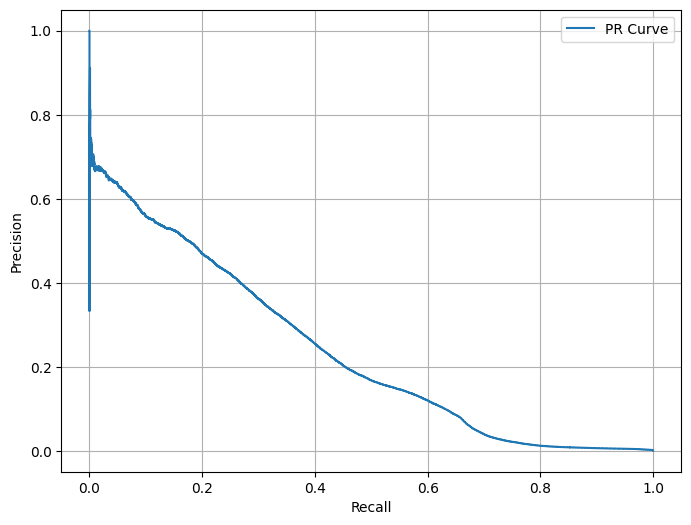

In [ ]:
auc_roc = roc_auc_score(y_test, y_pred)
auc_pr = average_precision_score(y_test, y_pred)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.96885735


In [ ]:
threshold = optimal_threshold
y_pred = (y_pred > threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00  22319671
           1       0.33      0.34      0.33     31001

    accuracy                           1.00  22350672
   macro avg       0.66      0.67      0.66  22350672
weighted avg       1.00      1.00      1.00  22350672



In [ ]:
threshold = 0.5
y_pred = (y_pred > threshold).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94  22319671
           1       0.01      0.84      0.02     31001

    accuracy                           0.89  22350672
   macro avg       0.50      0.86      0.48  22350672
weighted avg       1.00      0.89      0.94  22350672



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[22298123    21548]
 [   20607    10394]]


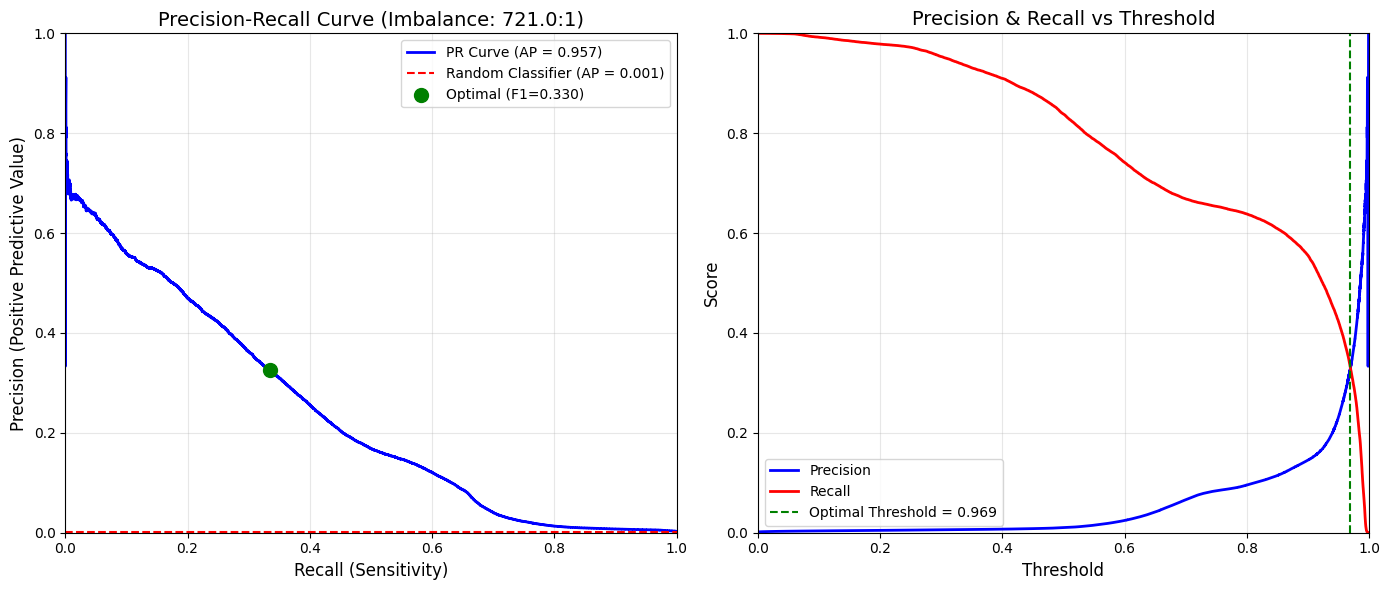

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_test.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:
print(len(y_pred))
n_customer = len(y_pred) / 24
idx_list = []
for i in range(int(n_customer)):
  start = i*24
  end = start+24
  customer_probs = y_pred[start:end]
  top_5_probs_idx = np.argsort(-customer_probs)[:3]
  top_5_probs_idx = top_5_probs_idx + start
  idx_list.extend(top_5_probs_idx)
y_test_top = y_test[idx_list]
y_pred_top = y_pred[idx_list]

22350672


In [ ]:
print(len(y_test_top))
print(len(y_pred_top))

2793834
2793834


Test data performance:
AUC-ROC: 0.9431
AUC-PR: 0.3066


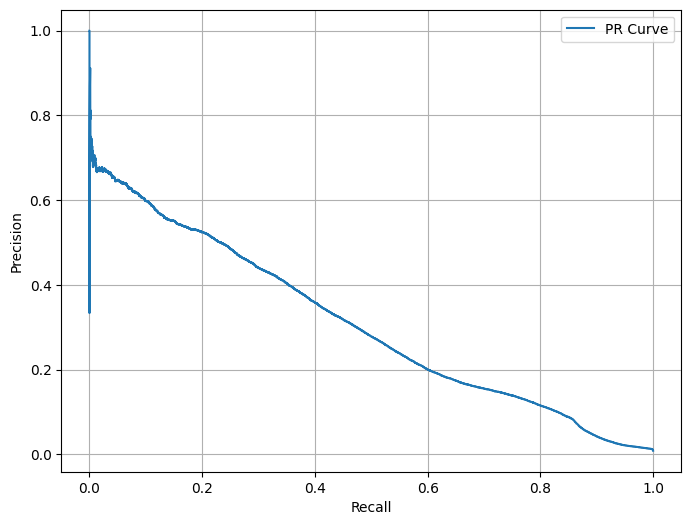

In [ ]:
auc_roc = roc_auc_score(y_test_top, y_pred_top)
auc_pr = average_precision_score(y_test_top, y_pred_top)
print(f"Test data performance:")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

precisions, recalls, thresholds = precision_recall_curve(y_test_top, y_pred_top)
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='PR Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:
f1_scores = 2*(precisions[:-1]*recalls[:-1])/(precisions[:-1]+recalls[:-1])
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold)

0.9754954


In [ ]:
threshold = optimal_threshold
y_pred = (y_pred_top > threshold).astype(int)
print(classification_report(y_test_top, y_pred_top))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00  22319671
           1       0.33      0.34      0.33     31001

    accuracy                           1.00  22350672
   macro avg       0.66      0.67      0.66  22350672
weighted avg       1.00      1.00      1.00  22350672



In [ ]:
threshold = 0.35582703
y_pred_top = (y_pred_top > threshold).astype(int)
print(classification_report(y_test_top, y_pred_top))

              precision    recall  f1-score   support

           0       1.00      0.42      0.59   2770569
           1       0.01      0.99      0.03     23265

    accuracy                           0.42   2793834
   macro avg       0.51      0.70      0.31   2793834
weighted avg       0.99      0.42      0.59   2793834



In [ ]:
print(confusion_matrix(y_test_top, y_pred_top))

[[22298123    21548]
 [   20607    10394]]


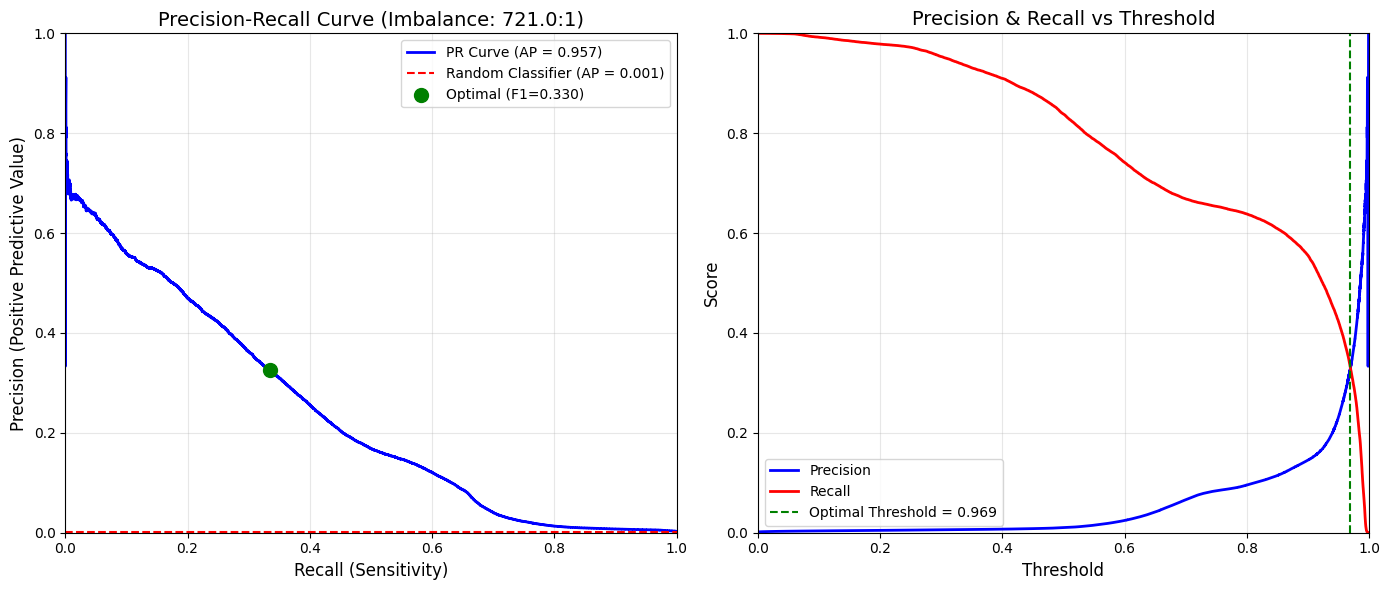

In [ ]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
baseline = y_test_top.mean()
optimal_f1 = f1_scores[optimal_idx]
optimal_precision = precisions[optimal_idx]
optimal_recall = recalls[optimal_idx]
# Plot 1: Precision-Recall Curve
ax1 = axes[0]
ax1.plot(recalls, precisions, 'b-', linewidth=2, label=f'PR Curve (AP = {auc_roc:.3f})')
ax1.axhline(y=baseline, color='r', linestyle='--', label=f'Random Classifier (AP = {baseline:.3f})')
ax1.scatter(optimal_recall, optimal_precision, color='green', s=100,
            zorder=5, label=f'Optimal (F1={optimal_f1:.3f})')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
ax1.set_title(f'Precision-Recall Curve (Imbalance: {1/baseline:.1f}:1)', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Plot 2: Precision and Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, precisions[:-1], 'b-', linewidth=2, label='Precision')
ax2.plot(thresholds, recalls[:-1], 'r-', linewidth=2, label='Recall')
ax2.axvline(x=optimal_threshold, color='green', linestyle='--',
            label=f'Optimal Threshold = {optimal_threshold:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:
def custom_validation(y_true, y_pred):
  true_index = y_true[]